## 1. Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from scipy.spatial import ConvexHull
import pulp
import bisect
import itertools

# For easy intersection checks (optional)
from shapely.geometry import Polygon as ShapelyPolygon

## 2. Helpers

In [7]:
def random_convex_polygon(num_vertices=5, center=(0,0), scale=1.0, angle_range=2*np.pi):
    """Generate a random convex polygon with given number of vertices."""
    angles = np.sort(np.random.uniform(0, angle_range, num_vertices))
    # Ensure the polygon is closed
    radii = np.random.uniform(0.5*scale, scale, num_vertices)
    x = center[0] + radii * np.cos(angles)
    y = center[1] + radii * np.sin(angles)
    points = np.column_stack([x, y])
    # Convex hull to guarantee convexity (may reduce vertex count)
    hull = ConvexHull(points)
    return points[hull.vertices]

def plot_polygons(polygons, colors=None, title="", ax=None):
    """Plot a list of polygons (each as Nx2 array)."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0,1,len(polygons)))
    for i, poly in enumerate(polygons):
        patch = MPLPolygon(poly, closed=True, facecolor=colors[i], 
                           edgecolor='black', alpha=0.6, linewidth=2)
        ax.add_patch(patch)
        # Label centroid
        centroid = np.mean(poly, axis=0)
        ax.text(centroid[0], centroid[1], f'{i}', ha='center', va='center', fontweight='bold')
    ax.set_aspect('equal')
    ax.autoscale()
    ax.set_title(title)
    return ax

def polygons_intersect(poly1, poly2):
    """Return True if two convex polygons intersect."""
    p1 = ShapelyPolygon(poly1)
    p2 = ShapelyPolygon(poly2)
    return p1.intersects(p2)

def find_intersecting_pairs(polygons):
    """Return list of (i,j) pairs of intersecting polygons."""
    n = len(polygons)
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            if polygons_intersect(polygons[i], polygons[j]):
                pairs.append((i,j))
    return pairs

## 3. LPs

In [8]:
def separating_axes(poly):
    """Return list of unit normal vectors for the edges of a convex polygon."""
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])   # perpendicular
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def project_polygon(poly, axis):
    """Project polygon onto axis, return (min, max)."""
    dots = np.dot(poly, axis)
    return np.min(dots), np.max(dots)

def build_separation_milp(polygons, max_move=15.0):
    """
    Build PuLP MILP to separate polygons by minimal translation.
    Returns: prob, dx_vars, dy_vars, status after solving.
    """
    n = len(polygons)
    prob = pulp.LpProblem("SeparatePolygons", pulp.LpMinimize)
    
    # Translation variables for each polygon
    dx = [pulp.LpVariable(f"dx_{i}", -max_move, max_move) for i in range(n)]
    dy = [pulp.LpVariable(f"dy_{i}", -max_move, max_move) for i in range(n)]
    
    # Objective: minimize sum of squared Euclidean distances (approximated by L1 sum of abs)
    # PuLP does not directly support squares, but we can use auxiliary variables for absolute values.
    abs_dx = [pulp.LpVariable(f"abs_dx_{i}", 0, max_move) for i in range(n)]
    abs_dy = [pulp.LpVariable(f"abs_dy_{i}", 0, max_move) for i in range(n)]
    for i in range(n):
        prob += dx[i] <= abs_dx[i]
        prob += -dx[i] <= abs_dx[i]
        prob += dy[i] <= abs_dy[i]
        prob += -dy[i] <= abs_dy[i]
    prob += pulp.lpSum(abs_dx[i] + abs_dy[i] for i in range(n))
    
    # For each pair of polygons
    for i, j in itertools.combinations(range(n), 2):
        # Collect all separating axes from both polygons
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        
        # For each axis, we will create constraints that, if selected, enforce separation.
        # We need a binary variable per axis per pair.
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))]
        # Exactly one axis must separate the pair (i.e., at least one z = 1)
        prob += pulp.lpSum(z) >= 1
        
        # For each axis, add the separation constraints (only active if z_k = 1)
        M = 1000  # big-M
        for k, axis in enumerate(all_axes):
            # Project original polygons onto axis
            min_i, max_i = project_polygon(polygons[i], axis)
            min_j, max_j = project_polygon(polygons[j], axis)
            # After translation, the intervals become:
            # [min_i + dot(axis, (dx_i,dy_i)), max_i + dot(axis, (dx_i,dy_i))]
            # [min_j + dot(axis, (dx_j,dy_j)), max_j + dot(axis, (dx_j,dy_j))]
            dot_i = axis[0]*dx[i] + axis[1]*dy[i]
            dot_j = axis[0]*dx[j] + axis[1]*dy[j]
            
            # Two possibilities for separation: polygon i is left of j, or j is left of i.
            # We will enforce at least one of these two orderings using another binary.
            # But since we already have z_k selecting the axis, we can use it to activate either ordering.
            # Simplify: require max_i + dot_i <= min_j + dot_j   (i left of j)
            # OR       max_j + dot_j <= min_i + dot_i   (j left of i)
            # We'll use an auxiliary binary w for each axis to choose the order.
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            
            # If z_k = 1, one of the two orderings must hold.
            # Use big-M to deactivate constraints when z_k = 0.
            prob += max_i + dot_i - (min_j + dot_j) <= M * (1 - z[k]) + M * (1 - w)
            prob += max_j + dot_j - (min_i + dot_i) <= M * (1 - z[k]) + M * w
    
    return prob, dx, dy

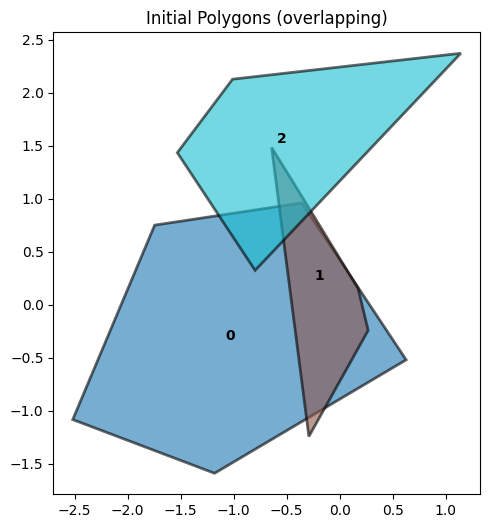

In [9]:
np.random.seed(42)  # for reproducibility
num_polygons = 3
polygons = []
centers = [(-1,0), (-1,0), (0,1)]   # deliberately close to force overlaps
for i in range(num_polygons):
    poly = random_convex_polygon(num_vertices=5, center=centers[i], scale=2.0)
    polygons.append(poly)

# Plot initial configuration
ax = plot_polygons(polygons, title="Initial Polygons (overlapping)")
plt.show()

# # Check intersections
# pairs = find_intersecting_pairs(polygons)
# print("Intersecting pairs:", pairs)

In [10]:
# Build and solve the separation model
prob, dx_vars, dy_vars = build_separation_milp(polygons)

# Solve (may take a few seconds)
solver = pulp.PULP_CBC_CMD(msg=True)
prob.solve(solver)

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Objective value: {pulp.value(prob.objective)}")

# Retrieve translations
translations = []
for i in range(len(polygons)):
    tx = pulp.value(dx_vars[i])
    ty = pulp.value(dy_vars[i])
    translations.append((tx, ty))
    print(f"Polygon {i}: dx={tx:.3f}, dy={ty:.3f}")

# Apply translations
separated_polygons = []
for i, poly in enumerate(polygons):
    tx, ty = translations[i]
    new_poly = poly + np.array([tx, ty])
    separated_polygons.append(new_poly)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/8ff945323b2540ba91154fcabdb9a9ef-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/8ff945323b2540ba91154fcabdb9a9ef-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 76 COLUMNS
At line 583 RHS
At line 655 BOUNDS
At line 730 ENDATA
Problem MODEL has 71 rows, 68 columns and 388 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0004I processed model has 71 rows, 68 columns (56 integer (56 of which binary)) and 388 elements
Cbc0038I Initial state - 6 integers unsatisfied sum - 0.375445
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 9.27885 iterations 7
Cbc0038I Solution found of 9.27885


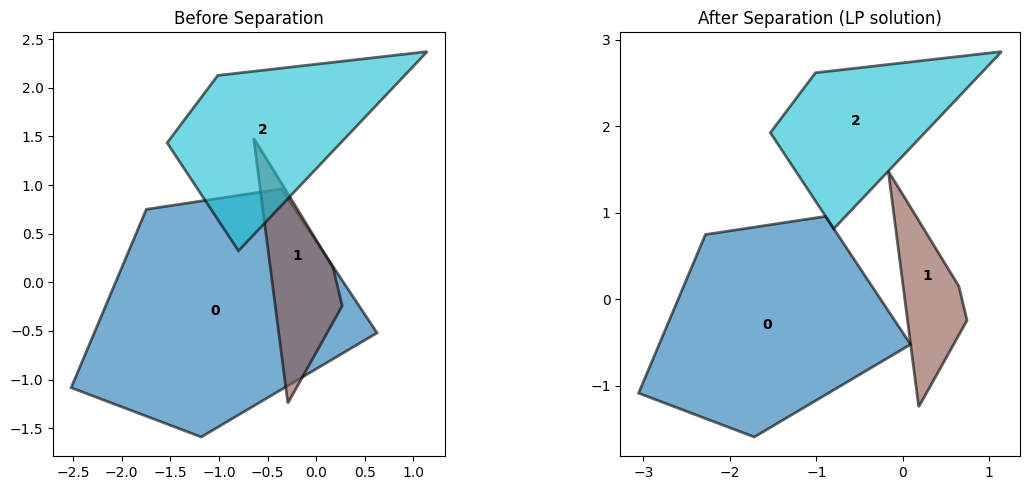

Intersecting pairs after separation: [(0, 1), (0, 2)]


In [11]:
# Plot before and after
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
plot_polygons(polygons, title="Before Separation", ax=ax1)
plot_polygons(separated_polygons, title="After Separation (LP solution)", ax=ax2)
plt.tight_layout()
plt.show()

# Verify no intersections remain
new_pairs = find_intersecting_pairs(separated_polygons)
print("Intersecting pairs after separation:", new_pairs)

Optimization warning: Iteration limit reached


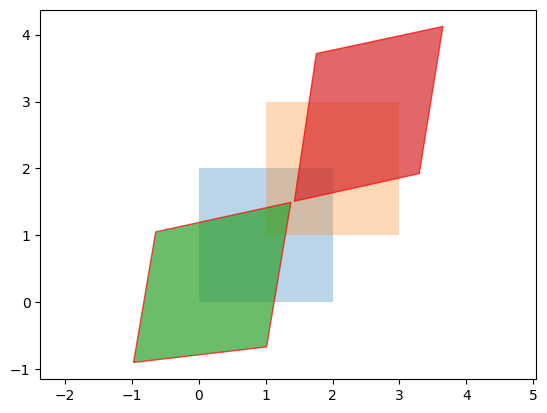

In [1]:
import numpy as np
from scipy.optimize import minimize, Bounds
from scipy.spatial import ConvexHull
from itertools import combinations

def polygon_area(poly):
    """Signed area of a polygon (list of (x,y) points)."""
    x = poly[:,0]
    y = poly[:,1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def project_polygon(poly, axis):
    dots = np.dot(poly, axis)
    return np.min(dots), np.max(dots)

def separating_axes(poly):
    """Return unit normals of edges (for convex polygons)."""
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def separation_violation(poly_i, poly_j):
    """
    Returns the maximum overlap (penetration) between two convex polygons.
    If negative, polygons are separated.
    """
    axes = separating_axes(poly_i) + separating_axes(poly_j)
    max_overlap = -np.inf
    for axis in axes:
        min_i, max_i = project_polygon(poly_i, axis)
        min_j, max_j = project_polygon(poly_j, axis)
        overlap = max(0, min(max_i, max_j) - max(min_i, min_j))
        max_overlap = max(max_overlap, overlap)
    return max_overlap

def deform_polygons(polygons, max_iter=100, tol=1e-6):
    """
    Deforms polygons to eliminate intersections while preserving each polygon's area.
    
    Parameters
    ----------
    polygons : list of (N_i,2) numpy arrays
        Initial convex polygons.
    max_iter : int
        Maximum number of optimization iterations.
    tol : float
        Tolerance on constraint violation.
    
    Returns
    -------
    new_polygons : list of (N_i,2) arrays
        Deformed, non‑intersecting polygons with same area as original.
    """
    n_poly = len(polygons)
    # Original areas
    orig_areas = [polygon_area(p) for p in polygons]
    # Flatten all vertices into one decision vector
    verts_per_poly = [len(p) for p in polygons]
    flat_start = np.concatenate([p.ravel() for p in polygons])
    
    def pack_variables(x):
        """Convert flat vector back to list of polygons."""
        polys = []
        idx = 0
        for nv in verts_per_poly:
            pts = x[idx:idx+2*nv].reshape(-1,2)
            polys.append(pts)
            idx += 2*nv
        return polys
    
    def objective(x):
        """Minimize sum of squared vertex displacements."""
        polys = pack_variables(x)
        diff = 0.0
        idx = 0
        for i, nv in enumerate(verts_per_poly):
            orig_flat = flat_start[idx:idx+2*nv]
            curr_flat = x[idx:idx+2*nv]
            diff += np.sum((curr_flat - orig_flat)**2)
            idx += 2*nv
        return diff
    
    def area_constraints(x):
        """Equality constraints: area of each polygon equals original area."""
        polys = pack_variables(x)
        cons = []
        for i, p in enumerate(polys):
            cons.append(polygon_area(p) - orig_areas[i])
        return np.array(cons)
    
    def separation_constraints(x):
        """Inequality constraints: separation violation <= 0 (i.e., no overlap)."""
        polys = pack_variables(x)
        cons = []
        for i, j in combinations(range(n_poly), 2):
            viol = separation_violation(polys[i], polys[j])
            cons.append(-viol)   # we require -viol <= 0  -> viol >= 0
        return np.array(cons)
    
    # Bounds: vertices can move within a bounding box (optional)
    # Here we allow relatively large movement (10× original extent)
    all_pts = np.vstack(polygons)
    min_coord = np.min(all_pts, axis=0) - 100
    max_coord = np.max(all_pts, axis=0) + 100
    bounds = Bounds(np.tile(min_coord, len(flat_start)//2),
                    np.tile(max_coord, len(flat_start)//2))
    
    # Constraints
    cons = [
        {'type': 'eq', 'fun': area_constraints},   # exact area preservation
        {'type': 'ineq', 'fun': separation_constraints}  # non‑overlap
    ]
    
    # Solve
    result = minimize(objective, flat_start, method='SLSQP',
                      bounds=bounds, constraints=cons,
                      options={'maxiter': max_iter, 'ftol': tol})
    
    if not result.success:
        print("Optimization warning:", result.message)
    
    return pack_variables(result.x)

# ========== Example usage ==========
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    # Two overlapping squares
    poly1 = np.array([[0,0], [2,0], [2,2], [0,2]])
    poly2 = np.array([[1,1], [3,1], [3,3], [1,3]])
    
    polygons = [poly1, poly2]
    deformed = deform_polygons(polygons)
    
    # Plot
    for p in polygons:
        hull = ConvexHull(p)
        plt.fill(p[hull.vertices,0], p[hull.vertices,1], alpha=0.3)
    for p in deformed:
        hull = ConvexHull(p)
        plt.fill(p[hull.vertices,0], p[hull.vertices,1], alpha=0.7, edgecolor='red')
    plt.axis('equal')
    plt.show()

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/60a8a0910e1d4dd382c2c3c38d317bd0-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/60a8a0910e1d4dd382c2c3c38d317bd0-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 470 COLUMNS
At line 2063 RHS
At line 2529 BOUNDS
At line 2754 ENDATA
Problem MODEL has 465 rows, 208 columns and 1288 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 128 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 128 strengthened rows, 0 substitutions
Cgl0003I 0 fixed, 0 tightened bounds, 128 strengthened rows, 0 substitutions
Cgl0004I processed model has 337 rows, 208 columns (144 integer (144 of which binary)) and 1288 element

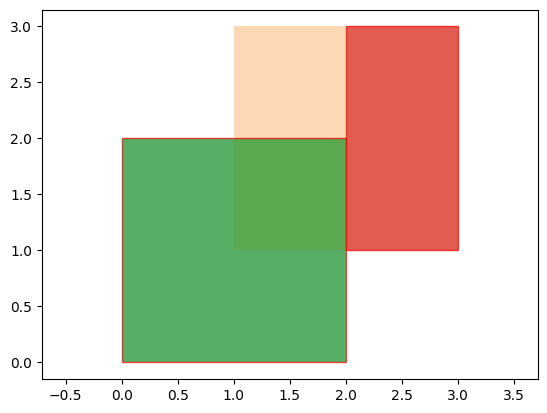

In [2]:
import pulp
import numpy as np
import itertools

def separating_axes(poly):
    """Return list of unit normal vectors for the edges of a convex polygon."""
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def build_deformation_milp(polygons, max_move=15.0, M=1000):
    """
    Build PuLP MILP to separate polygons by deforming vertices (no area/edge constraints).
    
    Parameters:
        polygons: list of (n_i,2) numpy arrays (convex polygons)
        max_move: maximum allowed displacement for any vertex (bound)
        M: big-M constant for logical constraints
    
    Returns:
        prob: PuLP problem
        vertex_vars: list of lists of (x_var, y_var) for each polygon's vertices
        status: solution status after solving (call prob.solve() externally)
    """
    n_poly = len(polygons)
    prob = pulp.LpProblem("DeformPolygons", pulp.LpMinimize)
    
    # ----- 1. Variables: each vertex becomes a free point -----
    vertex_vars = []      # vertex_vars[i][k] = (x_var, y_var)
    flat_original = []    # store original coordinates for objective
    for i, poly in enumerate(polygons):
        verts = []
        for k, (x0, y0) in enumerate(poly):
            x_var = pulp.LpVariable(f"x_{i}_{k}", -max_move, max_move)
            y_var = pulp.LpVariable(f"y_{i}_{k}", -max_move, max_move)
            verts.append((x_var, y_var))
            flat_original.append(x0)
            flat_original.append(y0)
        vertex_vars.append(verts)
    
    # ----- 2. Objective: minimise total L1 vertex displacement -----
    # Use auxiliary variables for absolute values
    abs_dx = []
    abs_dy = []
    idx = 0
    for i, poly in enumerate(polygons):
        for k, (x0, y0) in enumerate(poly):
            x_var, y_var = vertex_vars[i][k]
            ax = pulp.LpVariable(f"absx_{i}_{k}", 0, max_move)
            ay = pulp.LpVariable(f"absy_{i}_{k}", 0, max_move)
            prob += x_var - x0 <= ax
            prob += -(x_var - x0) <= ax
            prob += y_var - y0 <= ay
            prob += -(y_var - y0) <= ay
            abs_dx.append(ax)
            abs_dy.append(ay)
    prob += pulp.lpSum(abs_dx + abs_dy)
    
    # ----- 3. Separation constraints for each polygon pair -----
    for (i, j) in itertools.combinations(range(n_poly), 2):
        # Collect axes from both original polygons
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        n_axes = len(all_axes)
        
        # Binary variable: at least one axis must separate the pair
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(n_axes)]
        prob += pulp.lpSum(z) >= 1
        
        # For each axis, we need to enforce separation IF z[k]=1
        for k, axis in enumerate(all_axes):
            # For each polygon, we need min and max projection onto axis.
            # Introduce binary variables to select which vertex gives the min and which gives the max.
            n_vi = len(polygons[i])
            n_vj = len(polygons[j])
            
            # Variables for min and max projections of polygon i
            min_i = pulp.LpVariable(f"min_i_{i}_{j}_{k}", lowBound=None)
            max_i = pulp.LpVariable(f"max_i_{i}_{j}_{k}", lowBound=None)
            # Binary indicators for each vertex being the min / max
            delta_min_i = [pulp.LpVariable(f"dmin_i_{i}_{j}_{k}_{v}", cat=pulp.LpBinary) for v in range(n_vi)]
            delta_max_i = [pulp.LpVariable(f"dmax_i_{i}_{j}_{k}_{v}", cat=pulp.LpBinary) for v in range(n_vi)]
            
            # Exactly one vertex gives the min, one gives the max
            prob += pulp.lpSum(delta_min_i) == 1
            prob += pulp.lpSum(delta_max_i) == 1
            
            # min_i <= projection of each vertex
            for v, (x_var, y_var) in enumerate(vertex_vars[i]):
                proj = axis[0]*x_var + axis[1]*y_var
                prob += min_i <= proj
                # Big-M linking: if delta_min_i[v]==1 then min_i == proj
                prob += min_i >= proj - M*(1 - delta_min_i[v])
                prob += min_i <= proj + M*(1 - delta_min_i[v])
            
            # max_i >= projection of each vertex
            for v, (x_var, y_var) in enumerate(vertex_vars[i]):
                proj = axis[0]*x_var + axis[1]*y_var
                prob += max_i >= proj
                prob += max_i <= proj + M*(1 - delta_max_i[v])
                prob += max_i >= proj - M*(1 - delta_max_i[v])
            
            # Repeat for polygon j
            min_j = pulp.LpVariable(f"min_j_{i}_{j}_{k}", lowBound=None)
            max_j = pulp.LpVariable(f"max_j_{i}_{j}_{k}", lowBound=None)
            delta_min_j = [pulp.LpVariable(f"dmin_j_{i}_{j}_{k}_{v}", cat=pulp.LpBinary) for v in range(n_vj)]
            delta_max_j = [pulp.LpVariable(f"dmax_j_{i}_{j}_{k}_{v}", cat=pulp.LpBinary) for v in range(n_vj)]
            prob += pulp.lpSum(delta_min_j) == 1
            prob += pulp.lpSum(delta_max_j) == 1
            
            for v, (x_var, y_var) in enumerate(vertex_vars[j]):
                proj = axis[0]*x_var + axis[1]*y_var
                prob += min_j <= proj
                prob += min_j >= proj - M*(1 - delta_min_j[v])
                prob += min_j <= proj + M*(1 - delta_min_j[v])
                prob += max_j >= proj
                prob += max_j <= proj + M*(1 - delta_max_j[v])
                prob += max_j >= proj - M*(1 - delta_max_j[v])
            
            # Choose ordering: i left of j OR j left of i
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            # If z[k]=0, both constraints are deactivated; if z[k]=1, one ordering must hold.
            prob += max_i - min_j <= M*(1 - z[k]) + M*(1 - w)
            prob += max_j - min_i <= M*(1 - z[k]) + M*w
    
    return prob, vertex_vars

# ========== Example usage ==========
if __name__ == "__main__":
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.spatial import ConvexHull
    
    # Two overlapping squares
    poly1 = np.array([[0,0], [2,0], [2,2], [0,2]])
    poly2 = np.array([[1,1], [3,1], [3,3], [1,3]])
    polygons = [poly1, poly2]
    
    prob, vertex_vars = build_deformation_milp(polygons, max_move=5.0)
    prob.solve(pulp.PULP_CBC_CMD(msg=True))
    
    # Extract deformed polygons
    deformed = []
    for i, poly in enumerate(polygons):
        new_verts = []
        for k, (x_var, y_var) in enumerate(vertex_vars[i]):
            new_verts.append([x_var.varValue, y_var.varValue])
        deformed.append(np.array(new_verts))
    
    # Plot
    for p in polygons:
        hull = ConvexHull(p)
        plt.fill(p[hull.vertices,0], p[hull.vertices,1], alpha=0.3)
    for p in deformed:
        hull = ConvexHull(p)
        plt.fill(p[hull.vertices,0], p[hull.vertices,1], alpha=0.7, edgecolor='red')
    plt.axis('equal')
    plt.show()